### Initialize the Workspace

In [10]:
from workspace import Robot, Obstacle, Workspace

robot = Robot(base=(0, 0), link_lengths=(40, 30))
obs_1 = Obstacle(center_point=(20, 20), radius=7.0)
obs_2 = Obstacle(center_point=(60, 55), radius=11.0)

# bounds = (xmin, xmax, ymin, ymax) — sized to contain full arm reach
ws = Workspace(robot, obstacles=[obs_1, obs_2], bounds=(-75, 75, 0, 100))

### Forward Kinematics

Given joint angles (θ1, θ2), compute where the elbow and end-effector land in the workspace.

θ1=0°  θ2=0°  →  elbow=(np.float64(40.0), np.float64(0.0))  end_eff=(np.float64(70.0), np.float64(0.0))
θ1=90°  θ2=0°  →  elbow=(np.float64(0.0), np.float64(40.0))  end_eff=(np.float64(0.0), np.float64(70.0))
θ1=45°  θ2=-90°  →  elbow=(np.float64(28.28), np.float64(28.28))  end_eff=(np.float64(49.5), np.float64(7.07))


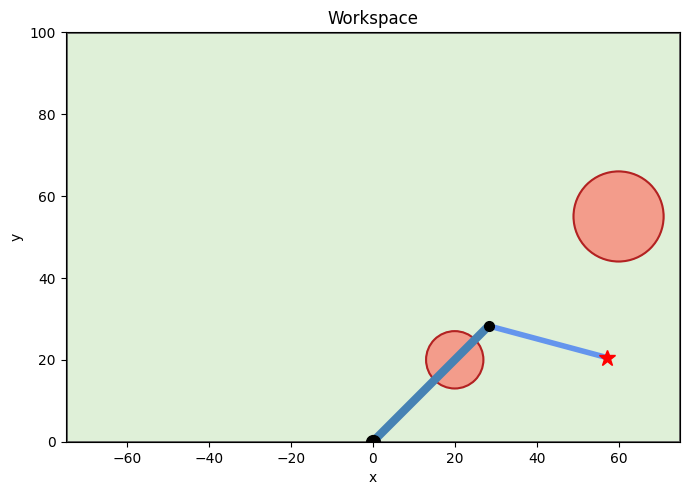

<Axes: title={'center': 'Workspace'}, xlabel='x', ylabel='y'>

In [ ]:
import numpy as np
from kinematics import forward_kinematics, inverse_kinematics, is_point_reachable
from visualization import draw_workspace

# sanity-check a few poses
for t1, t2 in [(0, 0), (np.pi/2, 0), (np.pi/4, -np.pi/2)]:
    elbow, end_eff = forward_kinematics(ws.robot, t1, t2)
    print(f"θ1={np.degrees(t1):.0f}°  θ2={np.degrees(t2):.0f}°  →  elbow={tuple(round(v,2) for v in elbow)}  end_eff={tuple(round(v,2) for v in end_eff)}")

draw_workspace(ws, theta1=np.pi/4, theta2=-np.pi/3)

### Inverse Kinematics

Given a target point (x, y) in the workspace, compute joint angles that place the end-effector there.
Two solutions (elbow-down / elbow-up) or none if the point is out of reach.

Target (40, 30): 2 solution(s)
  [0] θ1=0.0°  θ2=90.0°  →  end_eff=(np.float64(40.0), np.float64(30.0))
  [1] θ1=73.7°  θ2=-90.0°  →  end_eff=(np.float64(40.0), np.float64(30.0))


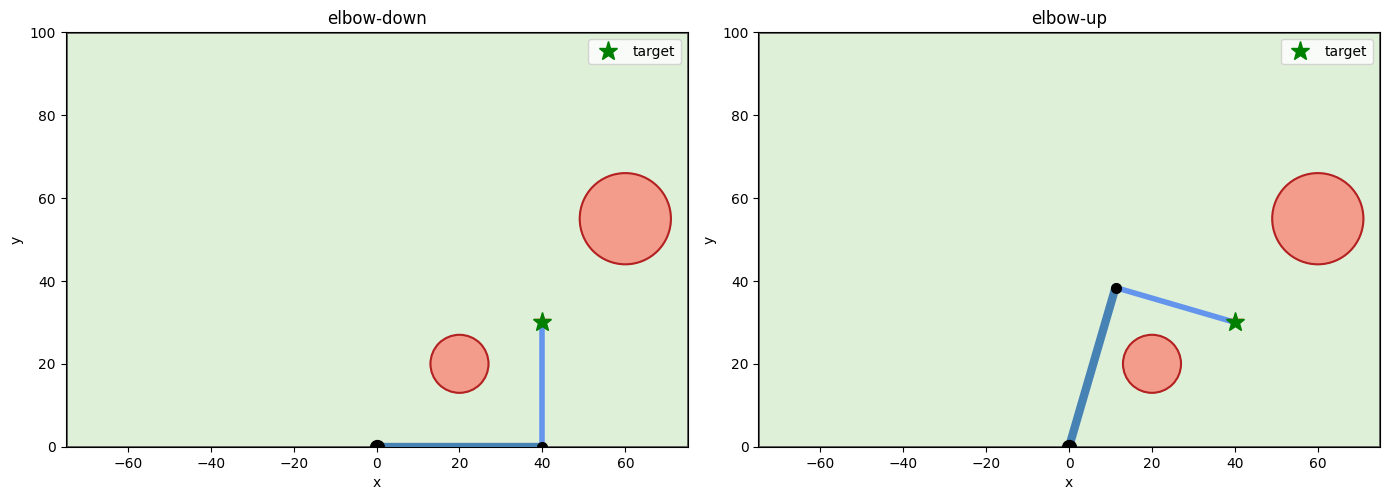


Target (200, 200): reachable=False  solutions=[]


In [12]:
import matplotlib.pyplot as plt

# target must be within the reachable annulus: dist in [|L1-L2|, L1+L2] = [10, 70]
target = (40, 30)  # dist ≈ 50 — comfortably reachable

solutions = inverse_kinematics(ws.robot, *target)
print(f"Target {target}: {len(solutions)} solution(s)")
for i, (t1, t2) in enumerate(solutions):
    elbow, end_eff = forward_kinematics(ws.robot, t1, t2)
    print(f"  [{i}] θ1={np.degrees(t1):.1f}°  θ2={np.degrees(t2):.1f}°  →  end_eff={tuple(round(v,2) for v in end_eff)}")

# draw both elbow solutions side by side
fig, axes = plt.subplots(1, len(solutions), figsize=(7 * len(solutions), 7))
if len(solutions) == 1:
    axes = [axes]
labels = ['elbow-down', 'elbow-up']
for ax, (t1, t2), label in zip(axes, solutions, labels):
    draw_workspace(ws, theta1=t1, theta2=t2, ax=ax, title=label)
    ax.plot(*target, 'g*', ms=14, zorder=5, label='target')
    ax.legend()
plt.tight_layout()
plt.show()

# verify unreachable point
far = (200, 200)
print(f"\nTarget {far}: reachable={is_point_reachable(ws.robot, *far)}  solutions={inverse_kinematics(ws.robot, *far)}")